# Bias Detection and Fairness 

NovaCred has received a regulatory inquiry regarding potential discrimination in its credit decision process. The following notebook will inspect NovaCred's historical credit application data, uncovering possible evidence of algorithmic bias and unfair practices in past credit decisions. While automation of such processes can improve consistency and speed, it also carries the risk of perpetuating historical discrimination patterns embedded in the data.

The following sections will therefore focus on: 
- **Gender Disparity:** Quantifying approval rate differences between gender groups and calculating the Disparate Impact (DI) ratio in accordance with the four-fifths rule.
- **Age-Based Bias:** Examining how approval rates and loan terms vary across age groups to detect potential discrimination against younger or older applicants.
- **Proxy Discrimination:** Investigating whether neutral variables such as ZIP code or spending behavior indirectly encode protected characteristics and influence decisions.
- **Interaction Effects:** Exploring combined effects of multiple protected attributes (e.g., gender and age) to reveal compounding disadvantages that isolated analyses may miss.
- **Loan Term Fairness:** Assessing whether approved interest rates and loan amounts differ systematically across groups with otherwise comparable financial profiles.

In [64]:
# Necessary imports
# Data manipulation 
import pandas as pd
import numpy as np
import os

# Statistics 
from scipy import stats
from scipy.stats import f_oneway

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Fairness
from fairlearn.metrics import demographic_parity_difference


First, we import and inspect the cleaned data that was transmitted by our data engineers. 

In [2]:
# Load cleaned dataset
data_path = os.path.join("..", "data", "cleaned_credit_applications.csv")
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 500 rows × 25 columns


,_id,spending_behavior,processing_timestamp,loan_purpose,notes,applicant_info_full_name,applicant_info_email,applicant_info_ssn,applicant_info_ip_address,applicant_info_gender,...,financials_savings_balance,decision_loan_approved,decision_rejection_reason,decision_interest_rate,decision_approved_amount,financials_annual_salary,financials_annual_income_canonical,analysis_dob_format,analysis_dob_parsed,analysis_age_years
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,NaN,NaN,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,...,31212.0,False,algorithm_risk_score,NaN,NaN,NaN,73000.0,YYYY-MM-DD (ISO),2001-03-09,24.985626
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,NaN,NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,...,17915.0,False,algorithm_risk_score,NaN,NaN,NaN,78000.0,YYYY-MM-DD (ISO),1992-03-31,33.924709
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,vacation,NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,...,37909.0,True,NaN,3.7,59000.0,NaN,61000.0,YYYY-MM-DD (ISO),1989-10-24,36.358658
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,NaN,NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,...,0.0,True,NaN,4.3,34000.0,NaN,103000.0,YYYY-MM-DD (ISO),1983-04-25,42.858316
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,NaN,NaN,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,Male,...,31763.0,False,algorithm_risk_score,NaN,NaN,NaN,57000.0,YYYY-MM-DD (ISO),1999-05-21,26.787132


As in the following need for transformation still might arise, we will copy the cleaned dataframe.

In [3]:
df_bias = df.copy()

## 1. Gender Disparity 
Gender is a protected attribute under EU anti-discrimination law and is considered a sensitive characteristic under the EU AI Act, especially since credit scoring systems are classified as high-risk AI applications. It is therefore important to examine whether NovaCred’s historical lending decisions show systematic differences in approval outcomes across gender groups, even if gender is not directly used as a model input.

To assess this, we calculate the Disparate Impact (DI) Ratio, defined as:

$$DI = \frac{\text{Approval Rate (unprivileged group)}}{\text{Approval Rate (privileged group)}}$$

A DI ratio of 1.0 indicates equal approval rates. According to the commonly applied four-fifths rule, a DI below 0.8 suggests potential disparate impact, meaning one group is approved significantly less often than another.

The following analysis uses the columns: 
- `applicant_info_gender`: records the self-reported gender of each applicant, which serves as the protected attribute in this analysis
- `decision_loan_approved`: records the final lending decision for each application as a binary value,`True` if the loan was approved, `False` if it was denied

### 1.1 Data Preperation
Before calculating the DI ratio, we inspect both columns for inconsistencies and apply the necessary transformations to ensure they are ready for analysis.

In [4]:
print(df_bias["applicant_info_gender"].value_counts())
print(df_bias["applicant_info_gender"].isna().sum())

print(f"Records of gender entries: {len(df_bias)}")

applicant_info_gender
Female     251
Male       247
Unknown      2
Name: count, dtype: int64
0
Records of gender entries: 500


In [5]:
df_bias = df_bias[df_bias["applicant_info_gender"] != "Unknown"]
print(f"Records after removing unknown gender entries: {len(df_bias)}")

Records after removing unknown gender entries: 498


Two observations were labeled as "Unknown" for gender and were excluded from the analysis, as for the Disparate Impact calculation we need the clearly defined comparision groups (unpriviledged and priviledged).

In [6]:
print(df_bias["decision_loan_approved"].value_counts())
print(df_bias["decision_loan_approved"].dtype)

decision_loan_approved
True     290
False    208
Name: count, dtype: int64
bool


`decision_loan_approved` contains only clean `True/False` boolean values and requires no further cleaning. 

### 1.2 Disparate Impact Ratio 
We now calculate the Disparate Impact ratio to formally quantify the difference in approval rates between female and male applicants.

In [7]:
# Approval rates by gender
rates = df_bias.groupby('applicant_info_gender')['decision_loan_approved'].mean ()
female_rate = rates['Female'] 
male_rate = rates['Male'] 

print(f'Female rate: {female_rate:.4f}')
print(f'Male rate: {male_rate:.4f}')

# DI Ratio
di_ratio = female_rate/male_rate 

print(f"Disparate Impact Ratio: {di_ratio:.4f}")
print("Potential disparate impact detected!" if di_ratio < 0.8 else "DI ratio within acceptable range.")

Female rate: 0.5060
Male rate: 0.6599
Disparate Impact Ratio: 0.7667
Potential disparate impact detected!


The analysis yields a female approval rate of 50.6% compared to 66.0% for male applicants, which is a gap of over 15 percentage points. With a DI ratio of 0.767, the result falls below the four-fifths threshold of 0.8, indicating potential disparate impact against female applicants.

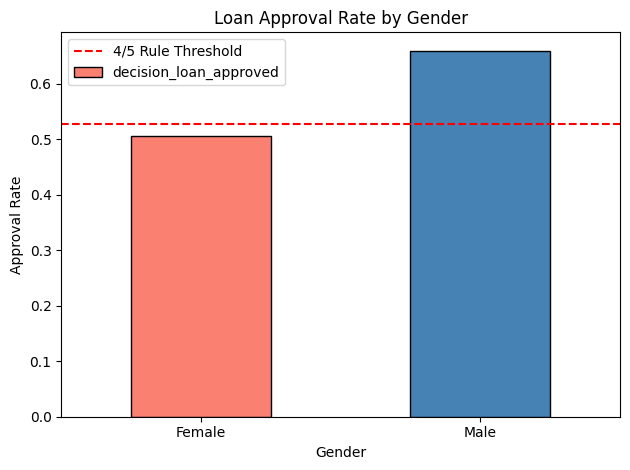

                       Total  Approved  Approval_Rate
applicant_info_gender                                
Female                   249       126         0.5060
Male                     246       162         0.6585


In [24]:
# Visualization: Bar chart by approval rate by gender
import matplotlib.pyplot as plt

rates.plot(kind="bar", color=["salmon", "steelblue"], edgecolor="black")
plt.title("Loan Approval Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Approval Rate")
plt.xticks(rotation=0)
plt.axhline(y=male_rate * 0.8, color="red", linestyle="--", label="4/5 Rule Threshold")
plt.legend()
plt.tight_layout()
plt.show()

# Summary Table 
summary = df_bias.groupby("applicant_info_gender")["decision_loan_approved"].agg(
    Total="count",
    Approved="sum",
    Approval_Rate="mean"
).round(4)
print(summary)

The bar chart clearly illustrates that female applicants are approved at a meaningfully lower rate than male applicants, with the female approval rate falling below the four-fifths rule threshold marked by the red dashed line. While this pattern is concerning, a disparity in approval rates alone does not conclusively prove discriminatory bias. It is possible that legitimate financial differences between groups, such as lower average income or higher debt-to-income ratios among female applicants, partially explain the gap. However, if the 
disparity persists after controlling for financial profile, it would constitute stronger evidence of bias. This effect will be looked at in a later stage of this notebook through proxy analysis and interaction effects.

### 1.3 Statistical significance - z-test

A DI ratio below 0.8 is a meaningful signal, but with a dataset of 498 applications it is important to verify that the observed difference in approval rates is statistically significant and not simply due to random variation. We apply a **two-proportion z-test**, as it is the standard method for comparing two independent proportions.

Hypothesis:

- **H₀ (Null Hypothesis):** There is no difference in approval rates between female and male applicants
- **H₁ (Alternative Hypothesis):** Female applicants have a significantly lower approval rate than male applicants

A p-value below 0.05 would allow us to reject the null hypothesis and treat the observed disparity as statistically significant.

In [9]:
from statsmodels.stats.proportion import proportions_ztest

# Get counts
gender_groups = df_bias.groupby("applicant_info_gender")["decision_loan_approved"]
n_female   = gender_groups.get_group("Female").count()
n_male     = gender_groups.get_group("Male").count()
app_female = gender_groups.get_group("Female").sum()
app_male   = gender_groups.get_group("Male").sum()

# Two-proportion z-test
count = np.array([app_female, app_male])
nobs  = np.array([n_female, n_male])
z_stat, p_value = proportions_ztest(count, nobs, alternative="smaller")

print(f"Z-statistic : {z_stat:.4f}")
print(f"P-value     : {p_value:.4f}")
print("Statistically significant disparity detected (p < 0.05)." if p_value < 0.05 
      else "No statistically significant disparity detected.")

Z-statistic : -3.4828
P-value     : 0.0002
Statistically significant disparity detected (p < 0.05).


### 1.4 Summary of Gender-Based Bias Findings

The gender-based analysis reveals a statistically significant disparity in loan approval 
rates between female and male applicants. The table below summarises the key findings:

| Pattern | Key Finding | Statistically Significant | Bias Detected |
|---|---|---|---|
| Approval Rates | Female approval rate of 50.6% vs 66.0% for male (DI = 0.767) | Yes (p = 0.0002) | ⚠️ Yes |

With a DI ratio of 0.767 falling below the four-fifths threshold and a highly significant 
p-value of 0.0002, the analysis confirms a meaningful fairness concern in NovaCred's 
lending decisions. Whether this disparity is driven by legitimate financial differences 
or reflects deeper systemic bias will be investigated further through proxy discrimination 
and interaction effects analysis in the following sections.

## 2. Age-based Bias
Age is also a protected characteristic under EU anti-discrimination law. If lending decisions systematically disadvantage applicants simply because they are younger or older, this raises a fairness concern, even if age is not directly used in the model. Similar to gender, age-related bias can still appear indirectly through other variables that are correlated with age.

The following analysis uses:
- `analysis_age_years`: the applicant's age in years, derived from `applicant_info_date_of_birth` by the Data Engineering pipeline
- `decision_loan_approved`: the binary outcome variable (approved/denied)
- `decision_interest_rate`: to assess whether approved loan terms differ across age groups
- `decision_approved_amount`: to assess whether loan amounts differ across age groups

### 2.1 Data Preperation
The `analysis_age_years` variable was already created in the Data Engineering pipeline based on `applicant_info_date_of_birth`. We checked it for missing values and removed 3 observations where age could not be calculated, since age group classification requires a valid numeric value. Age groups are then created based on the cleaned age variable since it is a continuous variable and enable group-level comparisons of approval rates.

The variables `applicant_info_gender` and `decision_loan_approved` were already reviewed and cleaned in the Gender Analysis. The `variables decision_interest_rate` and `decision_approved_amount` were validated in the data quality notebook. Both contain 207 missing values, which occur exclusively for denied applications and are therefore consistent with the dataset design and do not require further adjustment.

In [10]:
# Inspecting missing values or impossible ages 
print(df_bias["analysis_age_years"].describe())
print(f"\nMissing values: {df_bias['analysis_age_years'].isna().sum()}")
print(f"\nAge range: {df_bias['analysis_age_years'].min():.0f} - {df_bias['analysis_age_years'].max():.0f} years")

print(f"Records after removing missing age values: {len(df_bias)}")

count    495.000000
mean      41.204671
std       10.924274
min       23.860370
25%       32.431211
50%       39.485284
75%       47.481177
max       67.449692
Name: analysis_age_years, dtype: float64

Missing values: 3

Age range: 24 - 67 years
Records after removing missing age values: 498


In [11]:
# dropping the 3 rows with missing age values 
df_bias = df_bias.dropna(subset=["analysis_age_years"])
print(f"Records after removing missing age values: {len(df_bias)}")

Records after removing missing age values: 495


Four age groups are defined based on typical financial life stages instead of using arbitrary equal-width intervals. We find this approach is more meaningful, as people at different stages of life often have different financial characteristics — such as income levels, length of credit history, and savings behavior. Using life-stage groups therefore provides a more realistic basis for evaluating potential differences in credit decisions.

- 18–30: Early career, typically lower income and shorter credit history
- 31–45: Peak earning years, higher financial stability
- 46–60: Pre-retirement, typically highest savings and income
- 60+: Retirement age, fixed income patterns

In [12]:
# Define age bins and labels
bins   = [18, 30, 45, 60, 100]
labels = ["18-30", "31-45", "46-60", "60+"]

df_bias["age_group"] = pd.cut(
    df_bias["analysis_age_years"],
    bins=bins,
    labels=labels,
    right=True
)

print(df_bias["age_group"].value_counts().sort_index())

age_group
18-30     82
31-45    257
46-60    113
60+       43
Name: count, dtype: int64


C:\Users\lilik\AppData\Local\Temp\ipykernel_31004\2803368272.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bias["age_group"] = pd.cut(


In [13]:
# Inspect interest rate and approved amount
print(f"Missing values: {df_bias['decision_interest_rate'].isna().sum()}")

print(f"Missing values: {df_bias['decision_approved_amount'].isna().sum()}")

Missing values: 207
Missing values: 207


### 2.2 Age-based discrimination patterns

#### 2.2.1 Continuous Age Effect 
Before examining age groups, we first investigate whether a continuous relationship exists between age and loan approval. This avoids any artificial bias introduced by age group boundaries and reveals the overall direction of any age-related pattern. We use a 
point-biserial correlation coefficient, which is the appropriate measure for testing the relationship between a continuous variable (age) and a binary outcome (approved/denied).

- **H₀:** There is no correlation between age and loan approval
- **H₁:** There is a significant correlation between age and loan approval

Point-Biserial Correlation: 0.1220
P-value                   : 0.0066
Significant correlation detected (p < 0.05).


C:\Users\lilik\AppData\Local\Temp\ipykernel_31004\1630289536.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


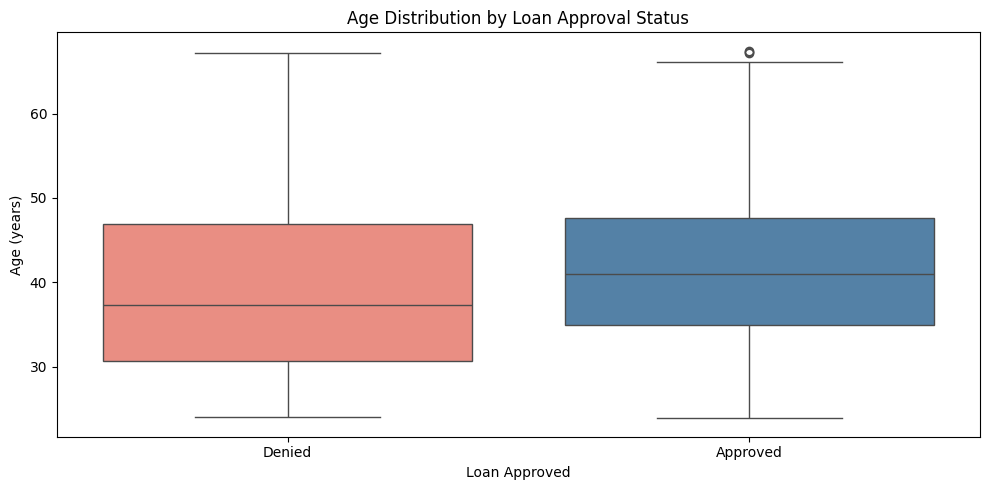

In [14]:
# Point-biserial correlation between age and approval
corr, p_value = stats.pointbiserialr(
    df_bias["analysis_age_years"],
    df_bias["decision_loan_approved"]
)

print(f"Point-Biserial Correlation: {corr:.4f}")
print(f"P-value                   : {p_value:.4f}")
print("Significant correlation detected (p < 0.05)." if p_value < 0.05
      else "No significant correlation detected.")

# Visualization: Age distribution by approval status
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_bias,
    x="decision_loan_approved",
    y="analysis_age_years",
    palette=["salmon", "steelblue"]
)
plt.title("Age Distribution by Loan Approval Status")
plt.xlabel("Loan Approved")
plt.ylabel("Age (years)")
plt.xticks([0, 1], ["Denied", "Approved"])
plt.tight_layout()
plt.show()

The point-biserial correlation (r = 0.122, p = 0.0066) shows a small but statistically significant positive relationship between age and loan approval, indicating that older applicants are slightly more likely to be approved. The box plot supports this pattern, with approved applicants having a somewhat higher median age (~41) than denied applicants (~38). Although the effect is modest, it appears unlikely to be due to chance and suggests a potential disadvantage for younger applicants.

#### 2.2.2 Approval Rate Differences Across Age Groups

Building on the continuous age effect, we now examine approval rates across the four defined age groups to identify which specific groups are most affected. A chi-square test of independence is used to assess whether the observed differences in approval rates across age groups are statistically significant.

- **H₀:** Loan approval is independent of age group
- **H₁:** Loan approval is significantly associated with age group

In [21]:
# Approval rates by age group
age_approval = df_bias.groupby("age_group")["decision_loan_approved"].agg(
    total="count",
    approved="sum",
    rate="mean"
).round(4)

# DI Ratio for all groups against highest performing group
max_rate        = age_approval["rate"].max()
privileged_group = age_approval["rate"].idxmax()

age_approval["di_ratio"]            = (age_approval["rate"] / max_rate).round(4)
age_approval["potential_di_impact"] = age_approval["di_ratio"].apply(
    lambda x: "⚠️ Yes" if x < 0.8 else "No"
)

# Summary table
print(f"Reference group (highest approval rate): {privileged_group} ({max_rate:.4f})\n")
print(age_approval[["total", "approved", "rate", "di_ratio", "potential_di_impact"]].to_string())

Reference group (highest approval rate): 60+ (0.6512)

           total  approved    rate  di_ratio potential_di_impact
age_group                                                       
18-30         82        34  0.4146    0.6367              ⚠️ Yes
31-45        257       156  0.6070    0.9321                  No
46-60        113        70  0.6195    0.9513                  No
60+           43        28  0.6512    1.0000                  No


C:\Users\lilik\AppData\Local\Temp\ipykernel_31004\2300508260.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_approval = df_bias.groupby("age_group")["decision_loan_approved"].agg(


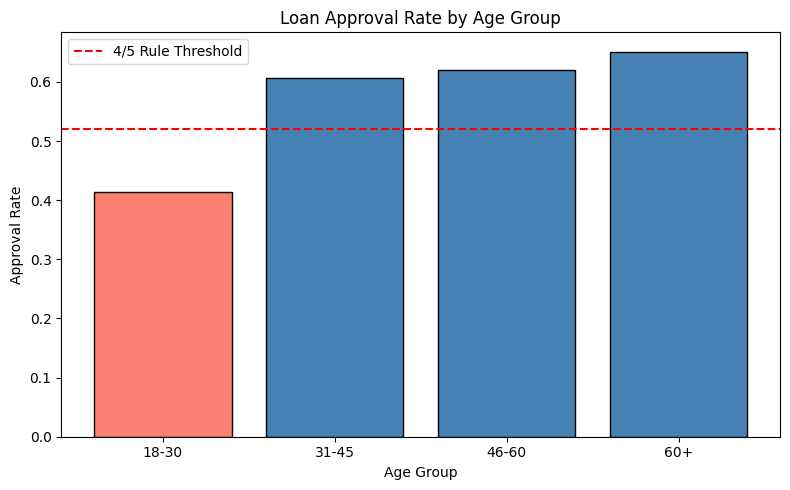

In [22]:
# Visualization: Bar chart of approval rates by age group
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    age_approval.index,
    age_approval["rate"],
    color=["salmon" if x < 0.8 else "steelblue" for x in age_approval["di_ratio"]],
    edgecolor="black"
)

ax.axhline(y=max_rate * 0.8, color="red", linestyle="--", label="4/5 Rule Threshold")
ax.set_title("Loan Approval Rate by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Approval Rate")
ax.legend()
plt.tight_layout()
plt.show()

The results reveal a disadvantage for the youngest applicant group. While the 31-45, 46-60 and 60+ groups show comparable approval rates between 60.7% and 65.1%. The 18-30 group has an approval rate of only 41.5%, yielding a DI ratio of 0.637, well below the four-fifths threshold. This suggests that young adults face a systematic disadvantage in NovaCred's lending decisions, potentially reflecting shorter credit histories and lower incomes typical of early career stages rather than deliberate discrimination. To see if the approval rates across age groups are statistically significant we run a chi-square test, as it is appropriate here to compare multiple groups (instead two, such as for the z-test). 

In [26]:
# Chi-square test of independence
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df_bias["age_group"], 
    df_bias["decision_loan_approved"]
)
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square statistic : {chi2:.4f}")
print(f"P-value              : {p_value:.4f}")
print("Significant association detected (p < 0.05)." if p_value < 0.05
      else "No significant association detected.")


Chi-square statistic : 11.5983
P-value              : 0.0089
Significant association detected (p < 0.05).


The chi-square test results (χ² = 11.60, df = 3, p = 0.0089) show a statistically significant relationship between age group and loan approval, as the p-value is below 0.05. This indicates that the differences in approval rates across age groups are unlikely to be due to chance.

#### 2.2.3 Interest rates across age groups

Age-related bias may also appear in the terms of approved loans, not only in approval decisions. Even if approval rates are similar, systematically different interest rates across age groups would indicate unequal treatment. We therefore analyze whether approved applicants in different age groups face statistically significant differences in interest rates.

- **H₀:** Mean interest rates are equal across all age groups
- **H₁:** At least one age group is charged a significantly different interest rate

In [27]:
# Filter to approved loans only
df_approved = df_bias[df_bias["decision_loan_approved"] == 1]

# Summary table: interest rates by age group
interest_summary = df_approved.groupby("age_group")["decision_interest_rate"].agg(
    count="count",
    mean_rate="mean",
    median_rate="median",
    std="std"
).round(4)
print(interest_summary)

           count  mean_rate  median_rate     std
age_group                                       
18-30         34     4.3176         4.25  1.0701
31-45        156     4.5436         4.50  1.1760
46-60         70     4.6643         4.70  1.1552
60+           28     4.7357         4.85  1.2573


C:\Users\lilik\AppData\Local\Temp\ipykernel_31004\1775828692.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interest_summary = df_approved.groupby("age_group")["decision_interest_rate"].agg(


C:\Users\lilik\AppData\Local\Temp\ipykernel_31004\2030218071.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


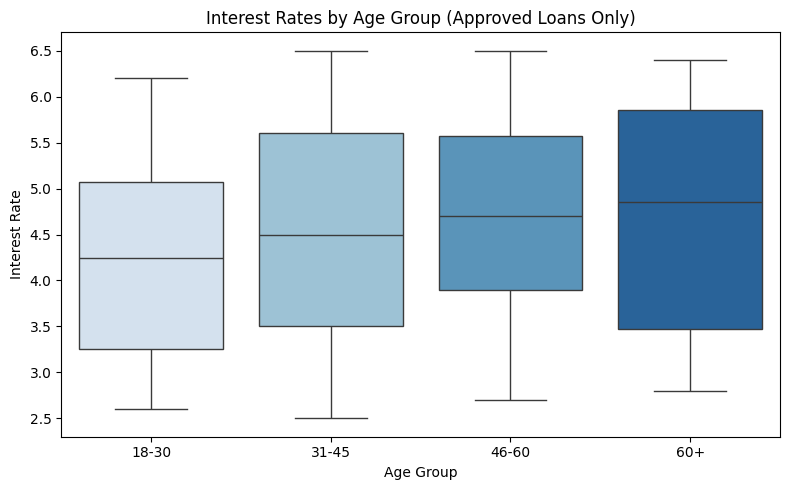

In [28]:
# Visualization: Box plot of interest rates by age group
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_approved,
    x="age_group",
    y="decision_interest_rate",
    palette="Blues"
)
plt.title("Interest Rates by Age Group (Approved Loans Only)")
plt.xlabel("Age Group")
plt.ylabel("Interest Rate")
plt.tight_layout()
plt.show()

In [29]:
# One-way ANOVA
from scipy.stats import f_oneway

groups = [
    df_approved[df_approved["age_group"] == g]["decision_interest_rate"].dropna()
    for g in df_approved["age_group"].cat.categories
]

f_stat, p_value = f_oneway(*groups)
print(f"\nF-statistic : {f_stat:.4f}")
print(f"P-value     : {p_value:.4f}")
print("Significant difference detected (p < 0.05)." if p_value < 0.05
      else "No significant difference in interest rates across age groups.")


F-statistic : 0.8949
P-value     : 0.4442
No significant difference in interest rates across age groups.


The one-way ANOVA tests whether mean interest rates differ significantly across age groups, producing a p-value to assess whether observed differences exceed what random 
variation alone could explain.

The summary statistics show a modest upward trend in mean interest rates with age, from 4.32% for the 18-30 group to 4.74% for the 60+ group. However, the ANOVA yields 
a p-value of 0.444, well above the 0.05 threshold, meaning these differences are not statistically significant. Unlike approval rates, interest rate assignment does not 
appear to reflect age-based bias in NovaCred's lending decisions.

#### 2.2.4 Approved Amounts Across Age Groups

Finally, we examine whether the approved loan amounts differ systematically across age groups. A one-way ANOVA test is again used to assess statistical significance.

- **H₀:** Mean approved amounts are equal across all age groups
- **H₁:** At least one age group receives a significantly different approved amount

In [30]:
# Summary table: approved amounts by age group
amount_summary = df_approved.groupby("age_group")["decision_approved_amount"].agg(
    count="count",
    mean_amount="mean",
    median_amount="median",
    std="std"
).round(2)
print(amount_summary)

           count  mean_amount  median_amount       std
age_group                                             
18-30         34     42205.88        39500.0  17528.82
31-45        156     48487.18        48000.0  17713.30
46-60         70     47528.57        48000.0  17795.72
60+           28     52214.29        58000.0  21042.03


C:\Users\lilik\AppData\Local\Temp\ipykernel_31004\2047036420.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  amount_summary = df_approved.groupby("age_group")["decision_approved_amount"].agg(


C:\Users\lilik\AppData\Local\Temp\ipykernel_31004\3908963704.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


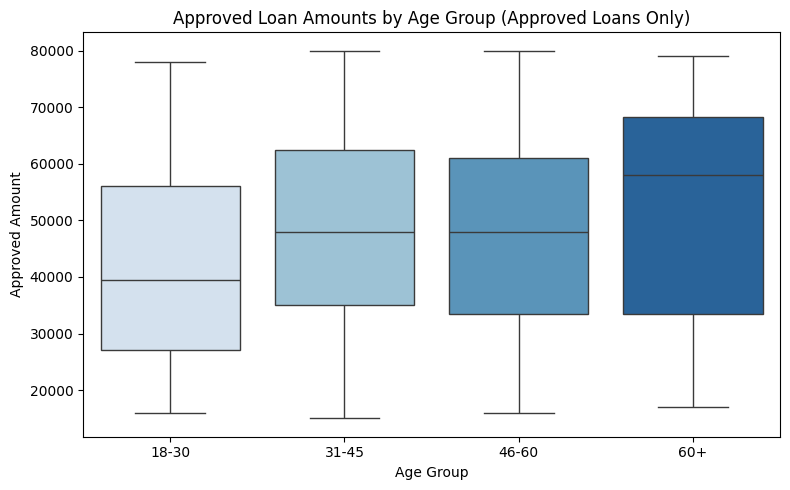

In [31]:
# Visualization: Box plot of approved amounts by age group
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_approved,
    x="age_group",
    y="decision_approved_amount",
    palette="Blues"
)
plt.title("Approved Loan Amounts by Age Group (Approved Loans Only)")
plt.xlabel("Age Group")
plt.ylabel("Approved Amount")
plt.tight_layout()
plt.show()

In [32]:
# One-way ANOVA
groups = [
    df_approved[df_approved["age_group"] == g]["decision_approved_amount"].dropna()
    for g in df_approved["age_group"].cat.categories
]

f_stat, p_value = f_oneway(*groups)
print(f"\nF-statistic : {f_stat:.4f}")
print(f"P-value     : {p_value:.4f}")
print("Significant difference detected (p < 0.05)." if p_value < 0.05
      else "No significant difference in approved amounts across age groups.")


F-statistic : 1.7249
P-value     : 0.1620
No significant difference in approved amounts across age groups.


The summary statistics show a slight upward trend in mean approved amounts with age — from €42,206 for the 18-30 group to €52,214 for the 60+ group. However, the ANOVA 
yields a p-value of 0.162, well above the 0.05 threshold, meaning these differences are not statistically significant. The box plot confirms this, showing broadly overlapping distributions across all groups. Similar to interest rates, approved loan amounts do not appear to reflect age-based bias in NovaCred's lending decisions.

### 2.3 Summary of Age-Based Bias Findings

The age-based analysis reveals that bias manifests primarily in **loan approval decisions** 
rather than in the terms of approved loans. The table below summarises the key findings 
across all four patterns investigated:

| Pattern | Key Finding | Statistically Significant | Bias Detected |
|---|---|---|---|
| Continuous Age Effect | Weak positive correlation (r = 0.122) between age and approval | Yes (p = 0.0066) | Mild |
| Approval Rates | 18-30 group approval rate of 41.5% vs 65.1% for 60+ (DI = 0.637) | Yes (p = 0.0089) | ⚠️ Yes |
| Interest Rates | Modest upward trend (4.32% → 4.74%) across age groups | No (p = 0.4442) | No |
| Approved Amounts | Slight upward trend (€42,206 → €52,214) across age groups | No (p = 0.1620) | No |

The most significant concern is the severe disadvantage faced by the 18-30 age group, 
whose DI ratio of 0.637 falls well below the four-fifths threshold. Once a loan is 
approved however, younger applicants do not appear to be penalised further through 
higher interest rates or lower loan amounts.

## 3. Proxy Discrimination

Proxy discrimination occurs when a variable that appears neutral on the surface indirectly encodes a protected characteristic. Effectively allowing a model to discriminate based on gender or age without explicitly using those attributes. This is particularly dangerous in automated credit scoring systems, as it can produce biased outcomes even when protected attributes are deliberately excluded from the model.

In this section we investigate the following variables as potential proxies:
- `applicant_info_zip_code` — geographic location may correlate with ethnicity or socioeconomic status
- `financials_debt_to_income` — may indirectly reflect the gender pay gap
- `financials_annual_income` — similarly may reflect structural income inequalities across gender groups
- `spending_behavior` — spending patterns may correlate with gender or age

### 3.1 Correlation Analysis
We first examine the correlation between key financial variables and loan approval to identify which variables are most strongly associated with the outcome. Variables 
with high correlation to approval are the most likely proxy candidates, and will be investigated further in subsequent steps.

In [33]:
# Select relevant financial variables: these are standard inputs to creditworthiness assessments
corr_vars = [
    "financials_annual_income",
    "financials_debt_to_income",
    "financials_credit_history_months",
    "financials_savings_balance",
    "analysis_age_years",
    "decision_loan_approved"
]

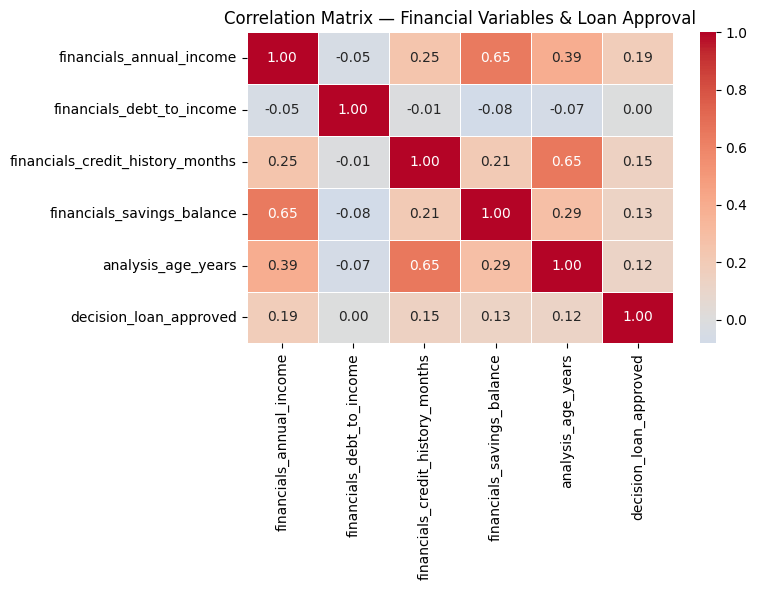

Correlations with loan approval:
financials_annual_income            0.1870
financials_credit_history_months    0.1467
financials_savings_balance          0.1327
analysis_age_years                  0.1220
financials_debt_to_income           0.0022
Name: decision_loan_approved, dtype: float64


In [34]:
# Correlation matrix
corr_matrix = df_bias[corr_vars].corr().round(4)

# Visualization: Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix — Financial Variables & Loan Approval")
plt.tight_layout()
plt.show()

# Print correlations with loan approval specifically
print("Correlations with loan approval:")
print(corr_matrix["decision_loan_approved"]
      .drop("decision_loan_approved")
      .sort_values(ascending=False))

The correlation analysis shows only weak positive relationships between financial variables and loan approval. The strongest associations are observed for:

- `annual_income` (r = 0.187)
- `credit_history_months` (r = 0.147)
- `savings_balance` (r = 0.133)

By contrast, `debt_to_income` shows almost no correlation with approval (r = 0.002), which is somewhat unexpected given its typical importance in credit decisions. While none of the variables strongly predicts approval on its own, `annual_income`, `credit_history_months`, and `savings_balance` emerge as the most plausible proxy candidates and will be examined further in the next steps.

### 3.2 Financial Profile Comparision
Having identified the financial variables most correlated with approval, we now examine whether these variables differ systematically across gender and age groups. If female 
or younger applicants show structurally lower incomes or shorter credit histories, these variables may be acting as proxies.

#### 3.2.1 Financial comparision by Gender

In [36]:
# Variables with the highest correlation with loan approval 
proxy_vars = [
    "financials_annual_income",
    "financials_credit_history_months",
    "financials_savings_balance"
]

In [43]:
print("=== Financial Profile by Gender ===")
print(df_bias.groupby("applicant_info_gender")[proxy_vars].mean().round(2))

=== Financial Profile by Gender ===
                       financials_annual_income  \
applicant_info_gender                             
Female                                 83814.01   
Male                                   81502.04   

                       financials_credit_history_months  \
applicant_info_gender                                     
Female                                            51.25   
Male                                              49.96   

                       financials_savings_balance  
applicant_info_gender                              
Female                                   29625.69  
Male                                     29630.27  


**Findings:** The financial profiles of female and male applicants are remarkably similar across all 
three variables: female applicants show marginally higher average income (€83,814 vs 
€81,502) and credit history (51.25 vs 49.96 months), with virtually identical savings 
balances. This is a critical finding, since female applicants are financially comparable 
to male applicants yet face significantly lower approval rates, the gender disparity 
identified in Section 1 cannot be attributed to legitimate financial differences, 
strengthening the case for systematic bias.

#### 3.2.2 Financial comparision by Age Group

C:\Users\lilik\AppData\Local\Temp\ipykernel_31004\100219920.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = df_bias.groupby("age_group")[var].agg(["mean", "std"])


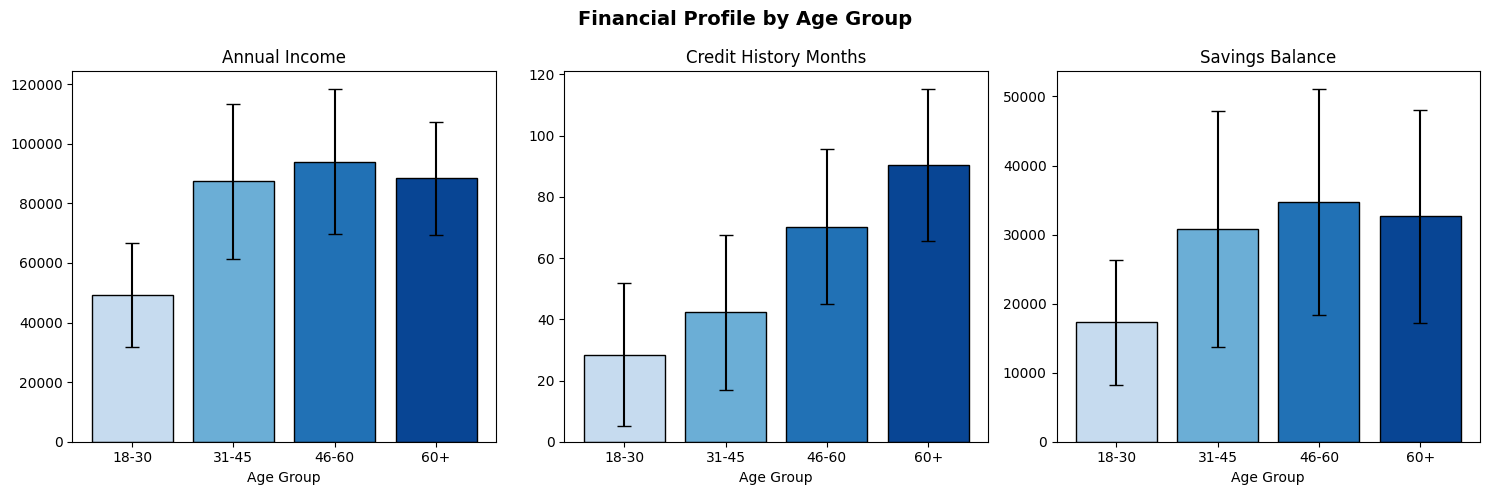


=== Financial Profile by Age Group ===
           financials_annual_income  financials_credit_history_months  \
age_group                                                               
18-30                      49178.18                             28.47   
31-45                      87388.24                             42.25   
46-60                      94018.02                             70.27   
60+                        88348.84                             90.37   

           financials_savings_balance  
age_group                              
18-30                        17273.54  
31-45                        30832.25  
46-60                        34724.33  
60+                          32625.16  


C:\Users\lilik\AppData\Local\Temp\ipykernel_31004\100219920.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_bias.groupby("age_group")[proxy_vars].mean().round(2))


In [45]:
# --- Age Group Comparison ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ["#c6dbef", "#6baed6", "#2171b5", "#084594"]

for ax, var in zip(axes, proxy_vars):
    group_means = df_bias.groupby("age_group")[var].agg(["mean", "std"])
    ax.bar(
        group_means.index,
        group_means["mean"],
        yerr=group_means["std"],
        color=colors,
        edgecolor="black",
        capsize=5
    )
    ax.set_title(var.replace("financials_", "").replace("_", " ").title())
    ax.set_xlabel("Age Group")
    ax.set_ylabel("")

fig.suptitle("Financial Profile by Age Group", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


# Age group summary statistics
print("\n=== Financial Profile by Age Group ===")
print(df_bias.groupby("age_group")[proxy_vars].mean().round(2))

To confirm that the financial differences observed across age groups are statistically significant and not due to random variation, we apply a one-way ANOVA test for each 
financial variable. This tests whether the mean values differ significantly across the four age groups simultaneously.

- **H₀:** Mean values are equal across all age groups
- **H₁:** At least one age group differs significantly

In [65]:
# ANOVA
for var in proxy_vars:
    groups = [
        df_bias[df_bias["age_group"] == g][var].dropna()
        for g in df_bias["age_group"].cat.categories
    ]
    f_stat, p_value = f_oneway(*groups)
    significance = "✓ Significant" if p_value < 0.05 else "✗ Not significant"
    print(f"{var:<40} F={f_stat:.4f}  p={p_value:.4f}  {significance}")

financials_annual_income                 F=65.6598  p=0.0000  ✓ Significant
financials_credit_history_months         F=90.2832  p=0.0000  ✓ Significant
financials_savings_balance               F=21.7746  p=0.0000  ✓ Significant


**Findings:** Unlike gender, the financial profiles differ substantially across age groups, particularly for the 18-30 group, which shows systematically lower values across 
all three variables:

| Variable | 18-30 | 31-45 | 46-60 | 60+ |
|---|---|---|---|---|
| Annual Income | €49,178 | €87,388 | €94,018 | €88,349 |
| Credit History | 28.47 months | 42.25 months | 70.27 months | 90.37 months |
| Savings Balance | €17,274 | €30,832 | €34,724 | €32,625 |

The 18-30 group earns on average 44% less than the 46-60 group, has accumulated less than a third of the credit history of the 60+ group, and holds savings roughly half the size of older groups. The box plots confirm these are not just mean differences but reflect systematically different distributions. This presents an important nuance. Unlike the gender disparity, the lower approval rate for younger applicants may be partially explained by these legitimate financial differences rather than pure discrimination. However, the magnitude of the approval gap (DI = 0.637) still warrants governance attention, as younger applicants are structurally disadvantaged by metrics that inherently correlate with age.

### 3.3 Zip Code Analysis 

Geographic location is one of the most commonly cited proxy variables in credit discrimination literature. ZIP codes can indirectly encode socioeconomic status, ethnicity, or other protected characteristics. Even if a model does not explicitly use protected attributes, approving or denying loans based on ZIP code can produce discriminatory outcomes if certain areas are disproportionately inhabited by protected groups.

We investigate this by examining:
1. Whether approval rates differ systematically across ZIP codes
2. Whether certain ZIP codes show a concentration of a particular gender or age group

#### 3.3.1 Zip Code Rates

In [52]:
print(df_bias["applicant_info_zip_code"].nunique())
print(df_bias["applicant_info_zip_code"].value_counts())

194
applicant_info_zip_code
10048.0    8
90284.0    7
10096.0    7
10004.0    6
10057.0    6
          ..
90289.0    1
30014.0    1
30043.0    1
10082.0    1
90220.0    1
Name: count, Length: 194, dtype: int64


As we can see, most Zip codes only appear 3 to 4 times (maximum 8), which makes a statistical comparision on individual Zip level for gender and age not really meaningful. Therefore, we will compare clusters of Zip codes: 

In [54]:
print(df_bias["applicant_info_zip_code"].astype(str).str[:2].value_counts())

applicant_info_zip_code
10    249
90    228
30     18
Name: count, dtype: int64


With 194 unique ZIP codes and only ~500 records, most ZIP codes contain too few applicants for meaningful statistical comparison. We therefore bundle them into regional groups based on their prefix, resulting in two main regions: New York (10XXX, 249 records) and Los Angeles (90XXX, 228 records). This allows us to examine whether approval rates differ systematically by region, and whether regions show a concentration of particular gender or age groups, which would indicate ZIP code is acting as a proxy for protected characteristics. The 30XXX group contains only 18 records, too few for reliable statistical conclusions, and is therefore excluded from this analysis.

In [56]:
# Create regional groups based on ZIP code prefix
def zip_to_region(zip_code):
    prefix = str(zip_code)[:2]
    if prefix == "10":
        return "New York"
    elif prefix == "90":
        return "Los Angeles"
    
df_bias["zip_region"] = df_bias["applicant_info_zip_code"].apply(zip_to_region)
print(df_bias["zip_region"].value_counts())

# Approval rates by region
region_approval = df_bias.groupby("zip_region")["decision_loan_approved"].agg(
    total="count",
    approved="sum",
    rate="mean"
).round(4)

# DI Ratio for regions
max_rate = region_approval["rate"].max()
privileged_region = region_approval["rate"].idxmax()
region_approval["di_ratio"]            = (region_approval["rate"] / max_rate).round(4)
region_approval["potential_di_impact"] = region_approval["di_ratio"].apply(
    lambda x: "⚠️ Yes" if x < 0.8 else "No"
)
print(f"\nReference group: {privileged_region} ({max_rate:.4f})\n")
print(region_approval)


zip_region
New York       249
Los Angeles    228
Name: count, dtype: int64

Reference group: New York (0.6426)

             total  approved    rate  di_ratio potential_di_impact
zip_region                                                        
Los Angeles    228       118  0.5175    0.8053                  No
New York       249       160  0.6426    1.0000                  No


C:\Users\lilik\AppData\Local\Temp\ipykernel_31004\193189339.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bias["zip_region"] = df_bias["applicant_info_zip_code"].apply(zip_to_region)


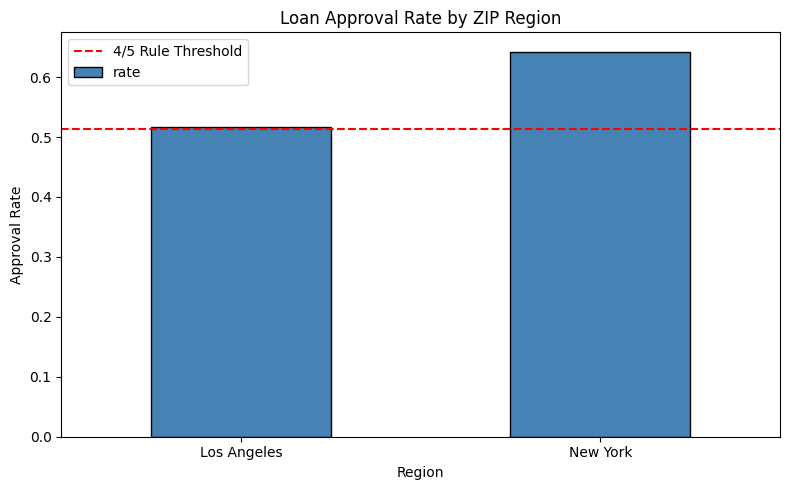

In [57]:
# Visualization: Approval rates by region
region_approval["rate"].plot(
    kind="bar",
    color=["salmon" if x < 0.8 else "steelblue" 
           for x in region_approval["di_ratio"]],
    edgecolor="black",
    figsize=(8, 5)
)
plt.title("Loan Approval Rate by ZIP Region")
plt.xlabel("Region")
plt.ylabel("Approval Rate")
plt.xticks(rotation=0)
plt.axhline(y=max_rate * 0.8, color="red", linestyle="--", label="4/5 Rule Threshold")
plt.legend()
plt.tight_layout()
plt.show()

New York applicants show a higher approval rate (64.3%) compared to Los Angeles applicants (51.8%), yielding a DI ratio of 0.805 and with this marginally above the four-fifths threshold. While this does not constitute disparate impact under the four-fifths rule, the proximity to the threshold warrants monitoring. We now examine whether this regional difference correlates with gender or age group distribution.

#### 3.3.2 Gender Distribution by Region


=== Gender Distribution by Region ===
applicant_info_gender  Female   Male
zip_region                          
Los Angeles             0.934  0.066
New York                0.112  0.888


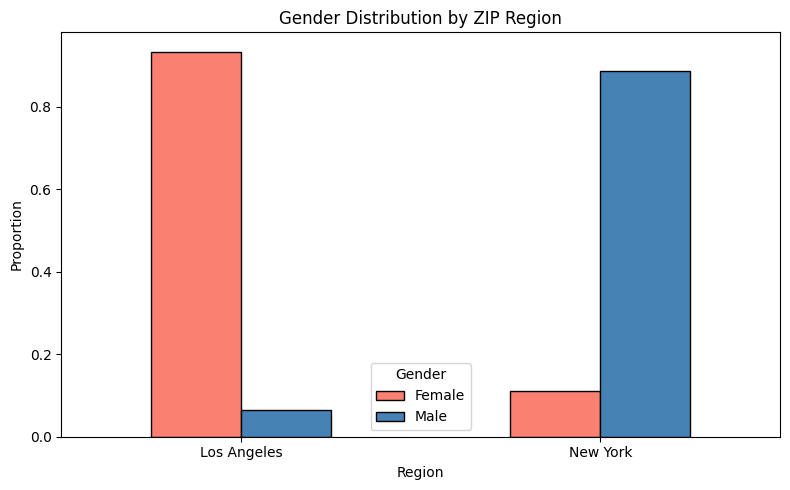

In [60]:
# Gender distribution by region
print("\n=== Gender Distribution by Region ===")
print(pd.crosstab(df_bias["zip_region"], 
                  df_bias["applicant_info_gender"], 
                  normalize="index").round(3))

gender_region = pd.crosstab(
    df_bias["zip_region"],
    df_bias["applicant_info_gender"],
    normalize="index"
).round(3)

gender_region.plot(
    kind="bar",
    color=["salmon", "steelblue"],
    edgecolor="black",
    figsize=(8, 5)
)
plt.title("Gender Distribution by ZIP Region")
plt.xlabel("Region")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

The gender distribution across regions reveals a pattern: Los Angeles applicants are 93.4% female while New York applicants are 88.8% male. This near-complete gender reversal between regions is highly unlikely to reflect natural demographic patterns, and strongly indicates that **ZIP code is acting as a proxy for gender** in this dataset. Since Los Angeles applicants are predominantly female and female applicants face lower approval rates, the regional approval gap identified earlier is likely driven by gender composition rather than geography itself.

We confirm this statistically and investigate if it is not due to random chance, by applying a chi-square test. 

- **H₀:** Gender distribution is independent of ZIP region
- **H₁:** Gender distribution differs significantly across ZIP regions

In [68]:
# Chi-square test for gender distribution across regions
contingency_table = pd.crosstab(
    df_bias["zip_region"],
    df_bias["applicant_info_gender"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic : {chi2:.4f}")
print(f"Degrees of freedom   : {dof}")
print(f"P-value              : {p_value:.4f}")
print("Significant association detected (p < 0.05)." if p_value < 0.05
      else "No significant association detected.")

Chi-square statistic : 318.2457
Degrees of freedom   : 1
P-value              : 0.0000
Significant association detected (p < 0.05).


The chi-square test confirms that the gender distribution across ZIP regions is highly unlikely to be due to random chance (χ² = 318.25, p < 0.0001). Combined with the near-complete gender reversal between regions — 93.4% female in Los Angeles vs 88.8% male in New York — this constitutes strong statistical evidence that ZIP code acts as a proxy for gender in NovaCred's dataset. This is a critical governance finding, as a model using ZIP code as an input variable would effectively discriminate based on gender without explicitly referencing it.

#### 3.3.3 Age Distribution by Region

In [62]:
# Age distribution by region (continuouse)
print("\n=== Mean Age by Region ===")
print(df_bias.groupby("zip_region")["analysis_age_years"].mean().round(2))

# Age groups distribution by region
print("\n=== Age Group Distribution by Region ===")
print(pd.crosstab(
    df_bias["zip_region"],
    df_bias["age_group"],
    normalize="index"
).round(3))


=== Mean Age by Region ===
zip_region
Los Angeles    41.71
New York       40.76
Name: analysis_age_years, dtype: float64

=== Age Group Distribution by Region ===
age_group    18-30  31-45  46-60    60+
zip_region                             
Los Angeles  0.167  0.487  0.254  0.092
New York     0.161  0.554  0.205  0.080


Age distribution is virtually identical across regions (41.71 vs 40.76 years), confirming that ZIP code does not act as a proxy for age. This is further confirmed by the age group distributions, which are broadly similar across both regions, confirming that ZIP code does not act as a proxy for age.

### 3.4 Summary of Proxy Discrimination Findings

The proxy discrimination analysis reveals that while no single variable perfectly explains the approval gaps identified in the Gender Disparate Impact and Age-Based Bias sections, several important patterns emerge that raise governance concerns.

| Analysis | Key Finding | Bias Detected |
|---|---|---|
| Correlation Analysis | `annual_income` (r=0.187) and `credit_history_months` (r=0.147) most correlated with approval | Weak signals |
| Financial Profile — Gender | Female applicants show equal or better financial profiles than male applicants | ⚠️ Yes, gap unexplained by financials |
| Financial Profile — Age | 18-30 group shows systematically lower income, credit history and savings | Partially explains age gap |
| ZIP Code — Approval Rates | Los Angeles DI ratio of 0.805 — marginally above threshold | No |
| ZIP Code — Gender Proxy | 93.4% female in LA vs 88.8% male in New York (χ² = 318.25, p < 0.0001) | ⚠️ Yes, strong proxy confirmed |

The most critical finding is that female applicants cannot be distinguished from male applicants on the basis of their financial profiles, yet face significantly lower approval 
rates. This rules out legitimate financial differences as an explanation for the gender gap and strengthens the case for systematic bias. Additionally, the confirmed use of ZIP 
code as a gender proxy represents a serious governance concern.

## 4. Interaction Effects 

The previous sections examined gender and age bias independently. However, protected attributes rarely operate in isolation, their combination can produce compounding disadvantages that are invisible when each attribute is analyzed separately. This section investigates whether certain subgroups defined by a combination of gender and age face disproportionately worse outcomes than either attribute alone would suggest, using approval rates across all gender × age group combinations.

### 4.1 Gender × Age Group Interaction

We first examine whether the gender gap in approval rates varies across age groups. A combined disadvantage for a specific subgroup, such as young female applicants, would not be visible when analyzing gender and age independently, making this interaction particularly important to investigate.

In [69]:
# Approval rates for gender x age group combinations
interaction = df_bias.groupby(
    ["age_group", "applicant_info_gender"]
)["decision_loan_approved"].agg(
    total="count",
    approved="sum",
    rate="mean"
).round(4)

print(interaction)

                                 total  approved    rate
age_group applicant_info_gender                         
18-30     Female                    44        15  0.3409
          Male                      38        19  0.5000
31-45     Female                   126        65  0.5159
          Male                     131        91  0.6947
46-60     Female                    56        32  0.5714
          Male                      57        38  0.6667
60+       Female                    23        14  0.6087
          Male                      20        14  0.7000


C:\Users\lilik\AppData\Local\Temp\ipykernel_31004\2691729661.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interaction = df_bias.groupby(


C:\Users\lilik\AppData\Local\Temp\ipykernel_31004\3295925995.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df_bias.groupby(


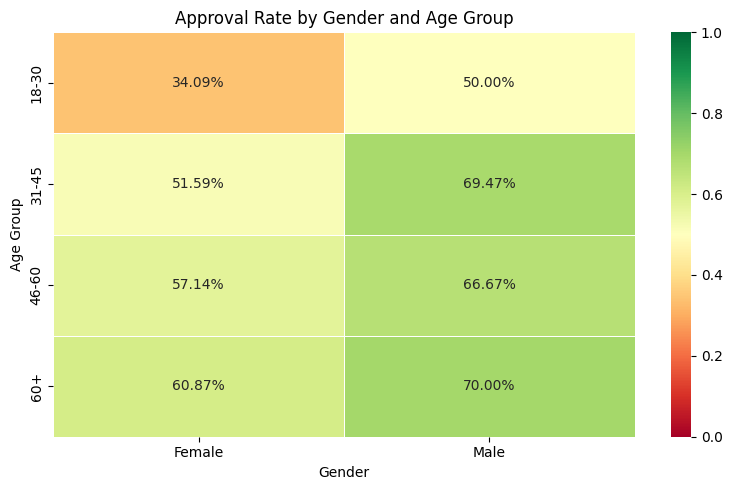

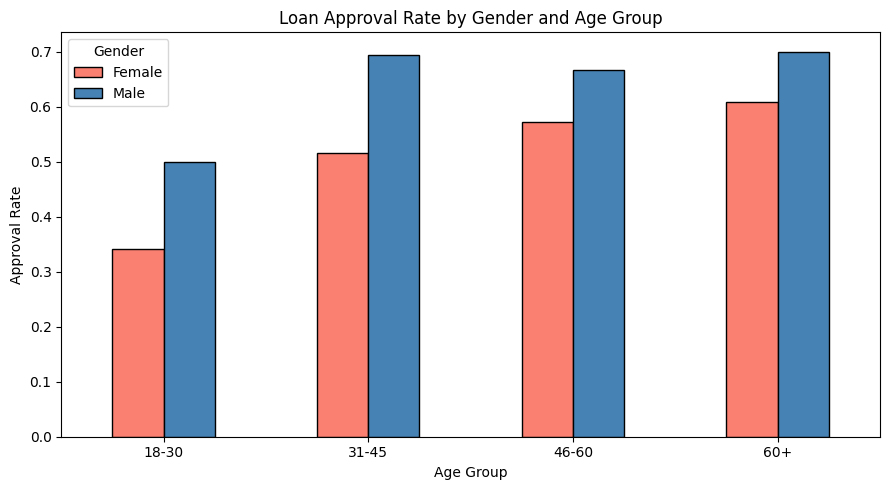

In [70]:
# Pivot for visualization
pivot = df_bias.groupby(
    ["age_group", "applicant_info_gender"]
)["decision_loan_approved"].mean().unstack()

# Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2%",
    cmap="RdYlGn",
    linewidths=0.5,
    vmin=0,
    vmax=1
)
plt.title("Approval Rate by Gender and Age Group")
plt.xlabel("Gender")
plt.ylabel("Age Group")
plt.tight_layout()
plt.show()

# Grouped bar chart
pivot.plot(
    kind="bar",
    color=["salmon", "steelblue"],
    edgecolor="black",
    figsize=(9, 5)
)
plt.title("Loan Approval Rate by Gender and Age Group")
plt.xlabel("Age Group")
plt.ylabel("Approval Rate")
plt.xticks(rotation=0)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

The interaction analysis reveals two important patterns. First, the gender gap in approval rates is consistent across all age groups: female applicants are approved less often than male applicants regardless of age, confirming that gender bias is not isolated to a specific life stage. Second, and most critically, young female applicants (18-30) face a severe compounding disadvantage with an approval rate of only 34.1% — the lowest of any subgroup — compared to 50.0% for young male applicants and 60.9% for older female applicants (60+). 

| Subgroup | Approval Rate |
|---|---|
| Female 18-30 | 34.1% ⚠️ |
| Male 18-30 | 50.0% |
| Female 31-45 | 51.6% |
| Male 31-45 | 69.5% |
| Female 46-60 | 57.1% |
| Male 46-60 | 66.7% |
| Female 60+ | 60.9% |
| Male 60+ | 70.0% |

This compounding effect, being both young and female, produces a disadvantage significantly worse than either attribute alone would suggest, and would remain invisible if gender and age were analyzed in isolation. The grouped bar chart clearly shows that while the gender gap narrows slightly with age, it never disappears entirely.

Even though it is highly likely that this interaction effect is significant, we apply a chi-square test on the full gender × age group contingency table to verify.

- **H₀:** Loan approval is independent of the gender × age group combination
- **H₁:** The gender × age group combination is significantly associated with loan approval

In [71]:
# Chi-square test for gender x age group interaction
contingency_table = pd.crosstab(
    df_bias["age_group"],
    df_bias["applicant_info_gender"],
    values=df_bias["decision_loan_approved"],
    aggfunc="sum"
)

# Full contingency table of counts
contingency_counts = pd.crosstab(
    [df_bias["age_group"], df_bias["applicant_info_gender"]],
    df_bias["decision_loan_approved"]
)

chi2, p_value, dof, expected = chi2_contingency(contingency_counts)

print(f"Chi-square statistic : {chi2:.4f}")
print(f"Degrees of freedom   : {dof}")
print(f"P-value              : {p_value:.4f}")
print("Significant interaction detected (p < 0.05)." if p_value < 0.05
      else "No significant interaction detected.")

Chi-square statistic : 23.5764
Degrees of freedom   : 7
P-value              : 0.0014
Significant interaction detected (p < 0.05).


### 4.2 Summary of Interaction Effects

The interaction analysis confirms that protected attributes do not operate in isolation. Their combination produces compounding disadvantages that would remain invisible when analyzing gender and age separately. The table below summarises the key finding:

| Interaction | Key Finding | Statistically Significant |
|---|---|---|
| Gender × Age Group | Female 18-30 approval rate of 34.1% — lowest of any subgroup | Yes (p < 0.05) |

The gender gap is consistent across all age groups, but compounds most severely for young female applicants, who face a double disadvantage from both their gender and age.

---

**Interactions not explicitly tested in this section:**

- **Gender × Financials:** Implicitly covered in Section 3.2, where we found that female and male applicants have virtually identical financial profiles across income, credit history and savings balance, meaning financial variables do not interact meaningfully with gender to produce additional disadvantage.

- **Age Groups × Financials:** Implicitly covered in Section 3.2, where we found that the 18-30 group shows systematically lower income (€49,178 vs €94,018 for 46-60), shorter credit history (28.47 vs 90.37 months) and lower savings (€17,274 vs €34,724), confirming that financial variables partially explain the age-based approval gap.

- **ZIP Region × Gender:** Implicitly covered in Section 3.3, where we confirmed that Los Angeles is 93.4% female while New York is 88.8% male (χ² = 318.25, p < 0.0001), 
  and that the regional approval gap is therefore largely driven by gender composition rather than geography itself.